# UDACITY DATA SCIENCE COURSE 2 FINAL PROJECT

## Section 1: Business Understanding

The aim of this project is to predict Developer Salary using 2025 Stackoverflow developer survey. We will use regression tree.

### Question 1: Which are the top respondents countries ?
### Question 2: What are the proportions of those using IA tools ?
### Question 3: Is using AI affects salary ?
### Question 4: Which variables affect the most salary ?

## Section 2: Data understanding

### Importing all necessary packages 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline

### Reading the Data

In [3]:
def import_csv(url):
    '''
    This function import csv file from any pathway including url
    
    input:
    url: pathw to csv file
    
    output:
    df: Dataframe 
    '''
    df = pd.read_csv(url)
    return df

url = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv"

df = import_csv(url)

# Create folder for saving output (results)
documents_folder = os.path.expanduser('~/Documents')
os.makedirs(documents_folder, exist_ok=True)

# Retained only the necessary colunms
retained_columns = ['MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl',
       'WorkExp', 'LearnCodeChoose', 'LearnCodeAI', 'YearsCode',
       'DevType', 'RemoteWork', 'Industry', 'AIThreat', 'NewRole',
       'Country', 'AISelect', 'AIAcc', 'ConvertedCompYearly']

df_subset = df[retained_columns].copy()


/tmp/ipykernel_13/1047539281.py:11: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


### Assessing the Data

   ResponseId                      MainBranch              Age  \
0           1  I am a developer by profession  25-34 years old   
1           2  I am a developer by profession  25-34 years old   
2           3  I am a developer by profession  35-44 years old   
3           4  I am a developer by profession  35-44 years old   
4           5  I am a developer by profession  35-44 years old   

                                           EdLevel  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1              Associate degree (A.A., A.S., etc.)   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
4  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   

                                          Employment  \
0                                           Employed   
1                                           Employed   
2  Independent contractor, freelancer, or self-em...   
3                                           Employed  

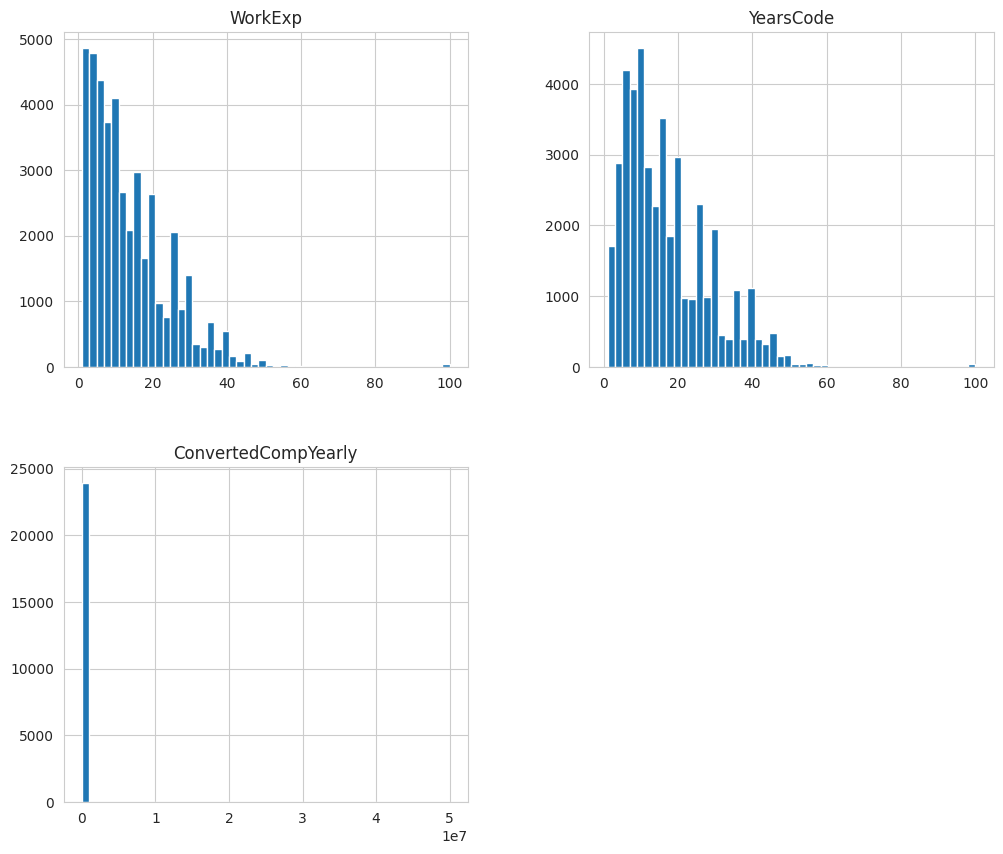


Descriptive Analysis of Retained Columns:
                            MainBranch              Age  \
count                            49191            49191   
unique                               6                7   
top     I am a developer by profession  25-34 years old   
freq                             37467            16519   
mean                               NaN              NaN   
std                                NaN              NaN   
min                                NaN              NaN   
25%                                NaN              NaN   
50%                                NaN              NaN   
75%                                NaN              NaN   
max                                NaN              NaN   

                                             EdLevel Employment  \
count                                          48149      48339   
unique                                             8          6   
top     Bachelor’s degree (B.A., B.S., B.Eng., 

In [4]:
print(df.head())
print('\nSubset shape:', df_subset.shape)

df_subset.info()

df_subset.hist(bins=50, figsize=(12, 10))
plt.show()

print(f'\nDescriptive Analysis of Retained Columns:')
print(df_subset.describe(include='all'))
print('\nMissing values:')
print(df_subset.isnull().sum())

# Identify numerical and categorical colunms
numeric_cols = df_subset.select_dtypes(include=['number']).columns.tolist()
cat_cols = df_subset.select_dtypes(exclude=['number']).columns.tolist()


### Descriptive analysis of the Data

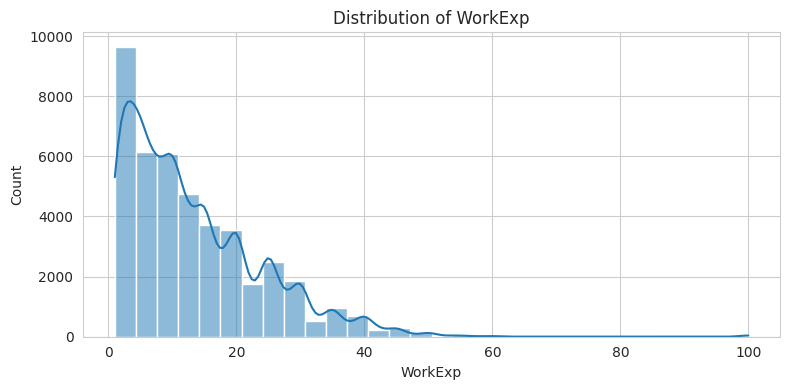

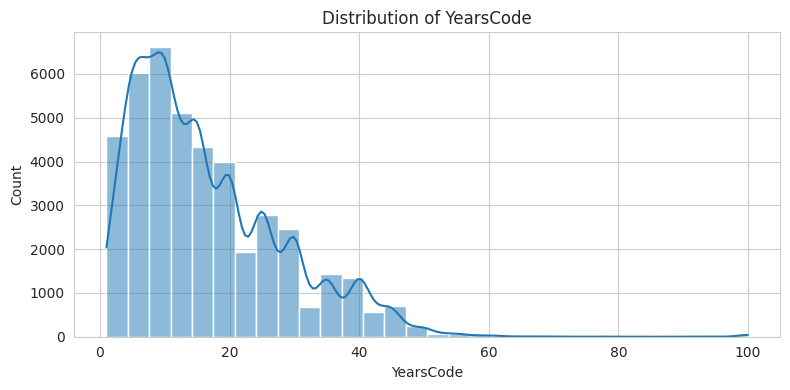

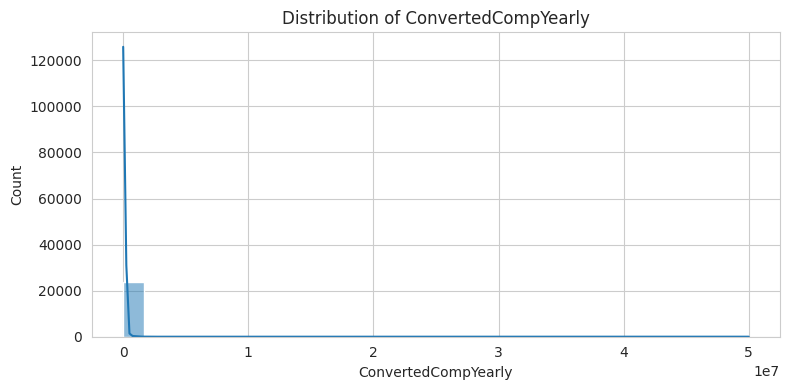

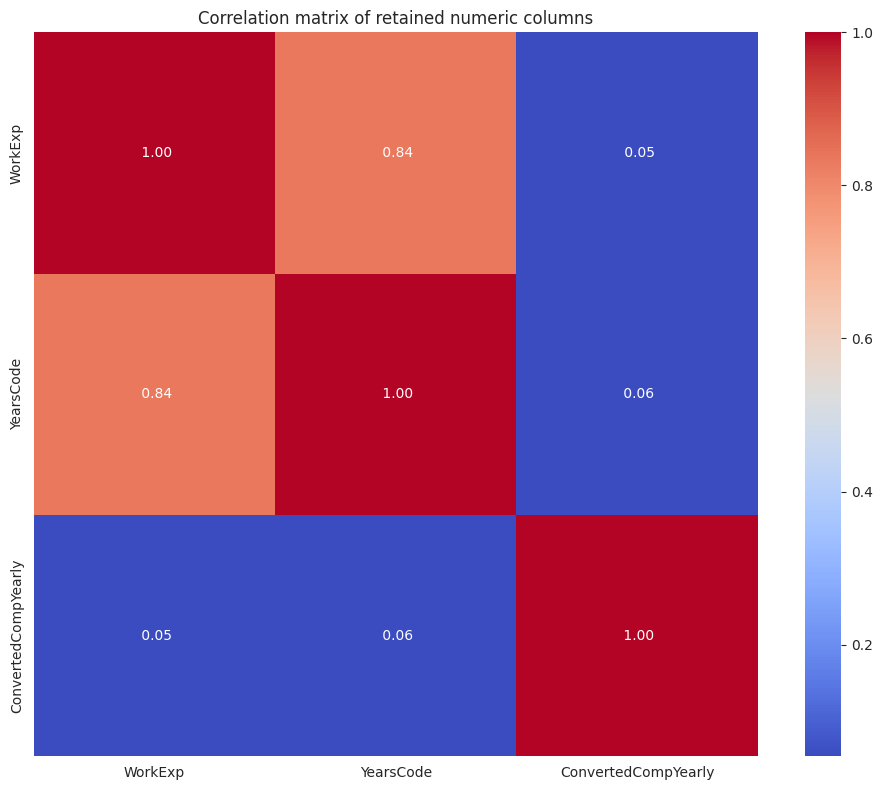

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


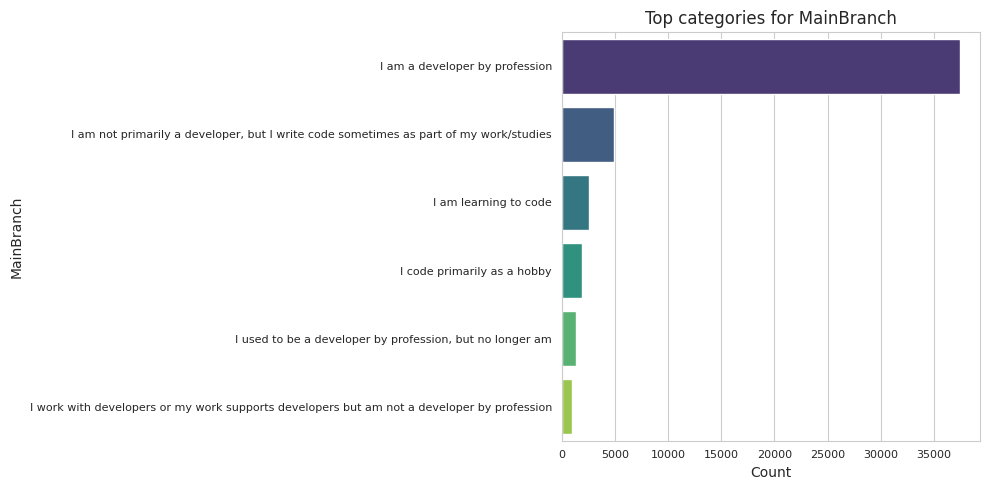

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


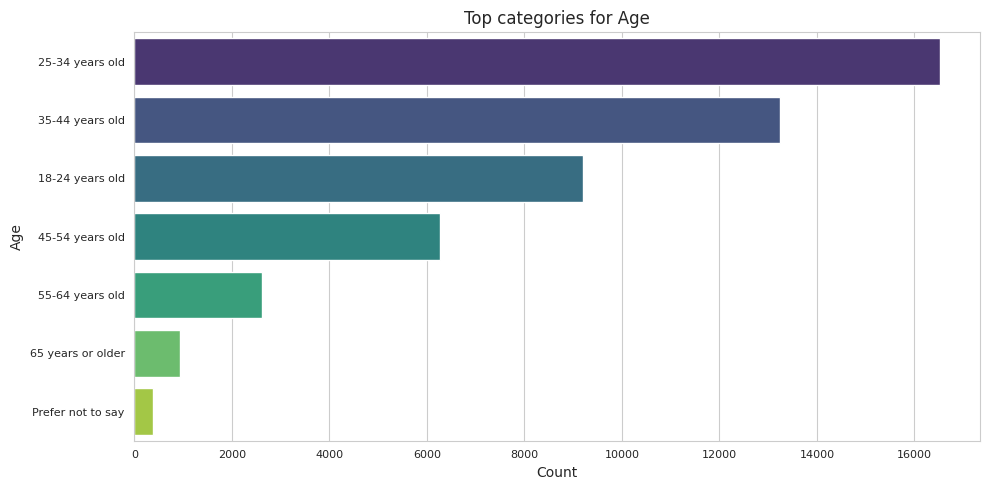

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


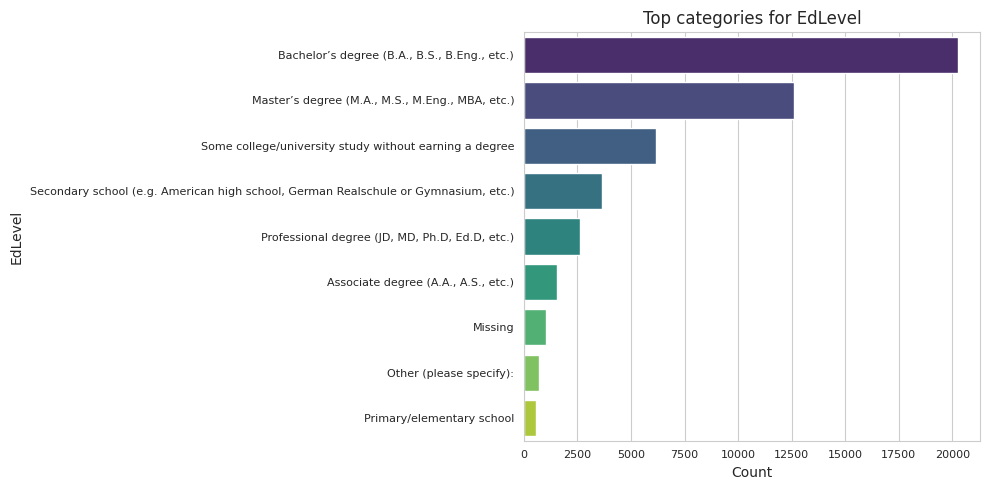

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


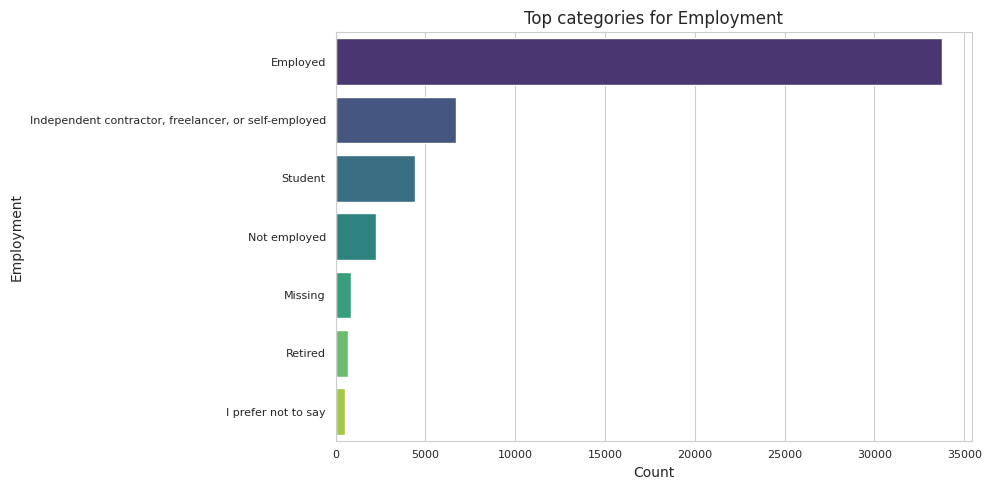

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


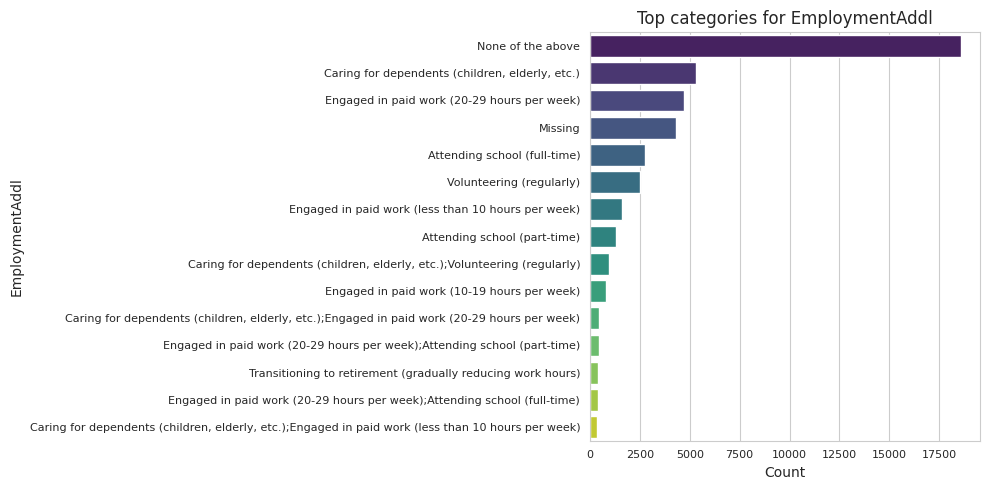

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


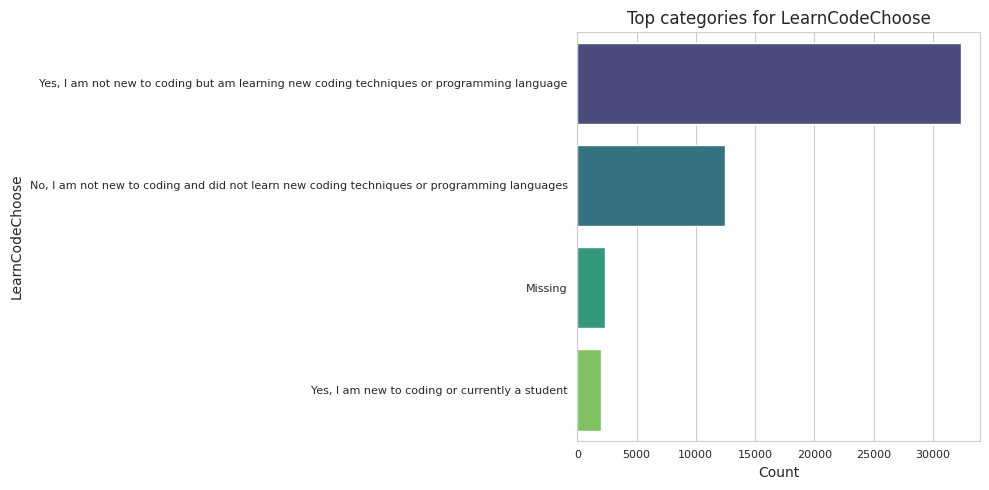

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


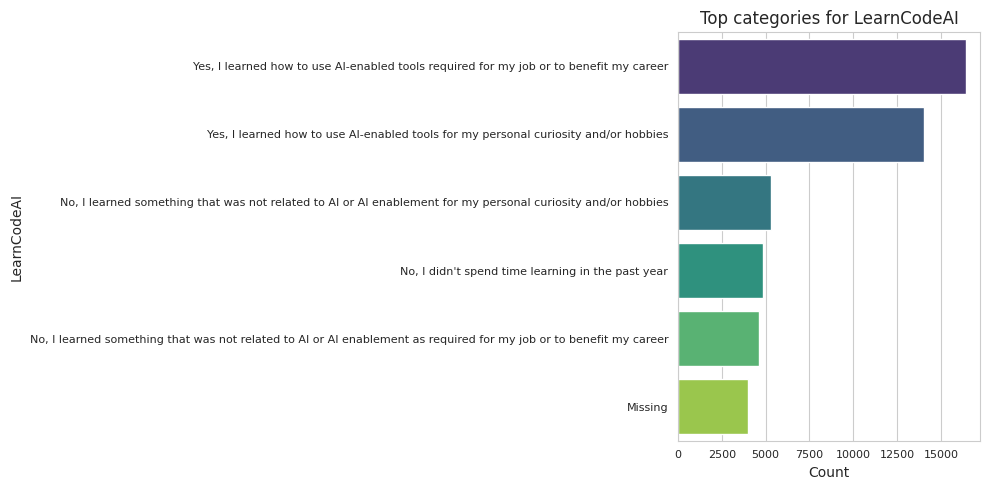

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


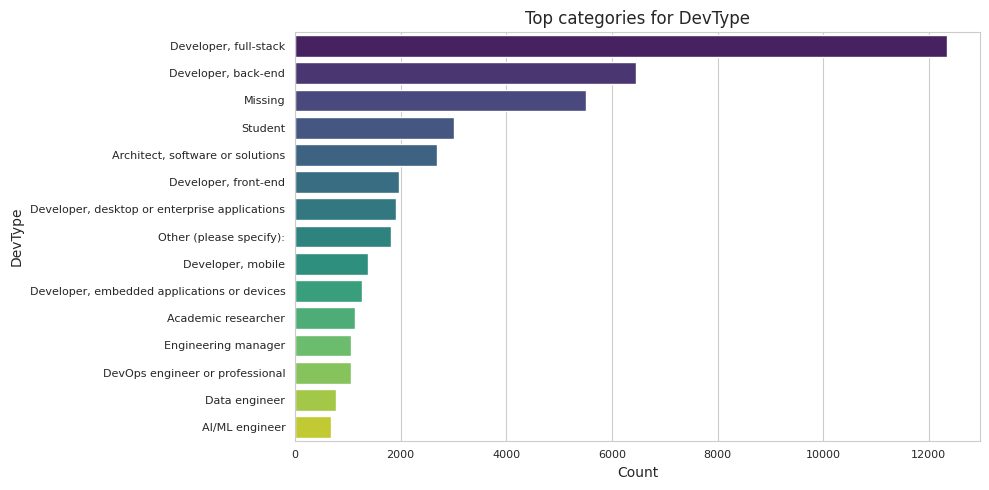

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


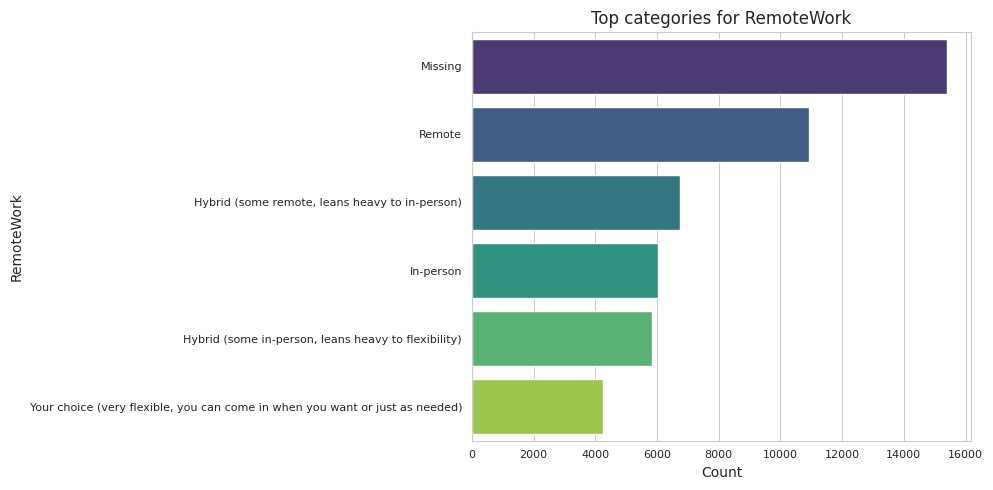

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


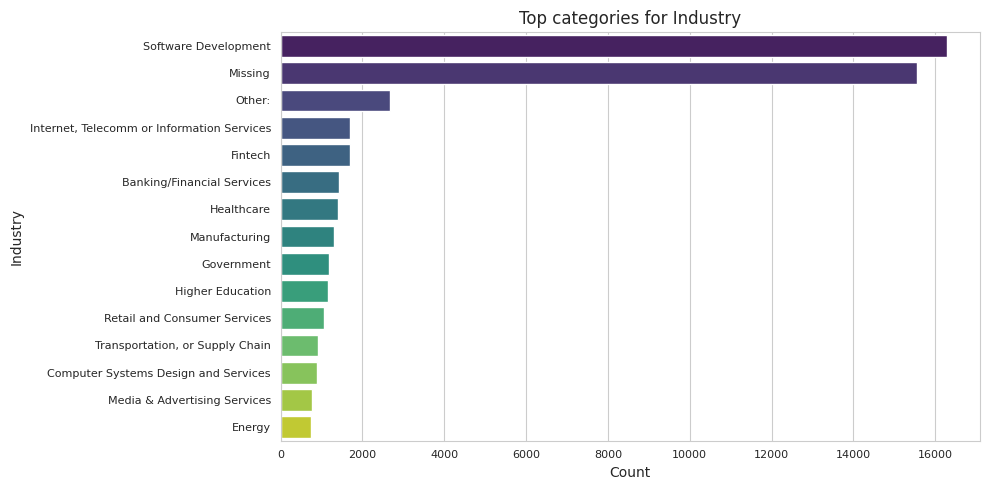

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


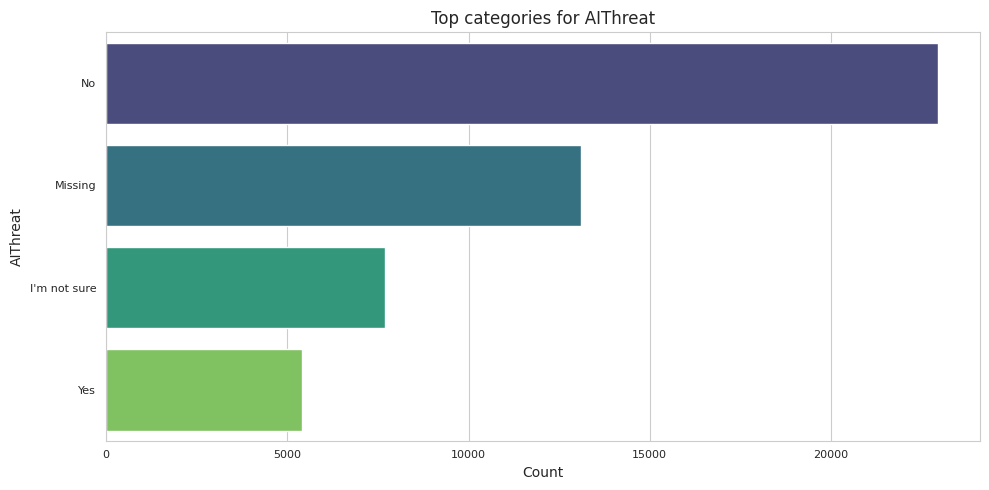

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


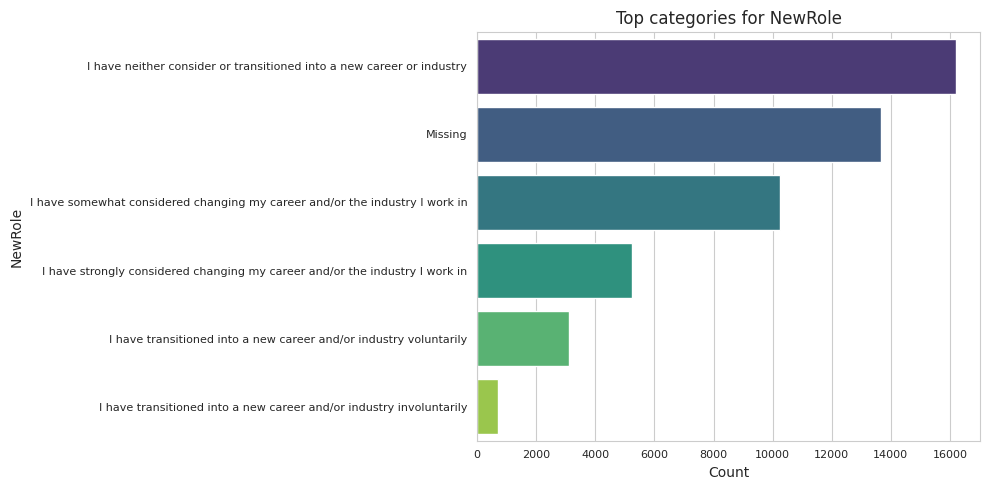

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


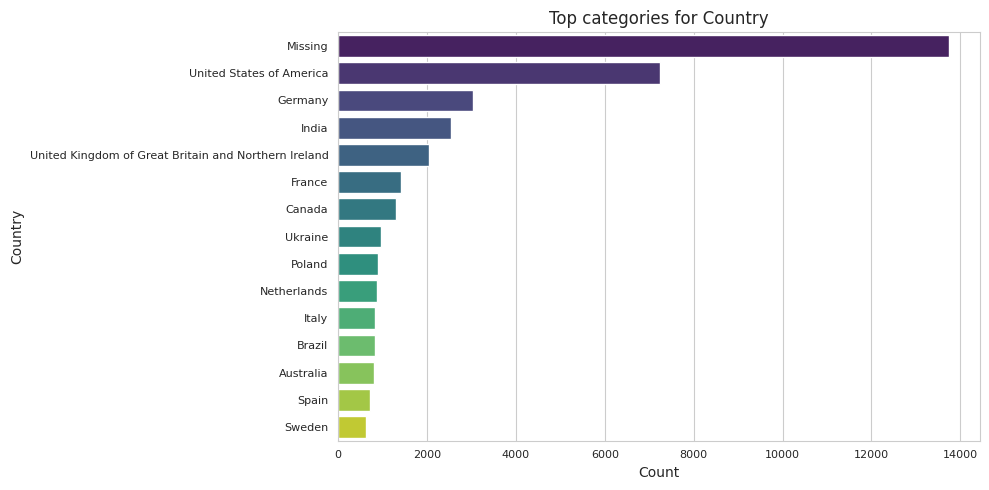

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


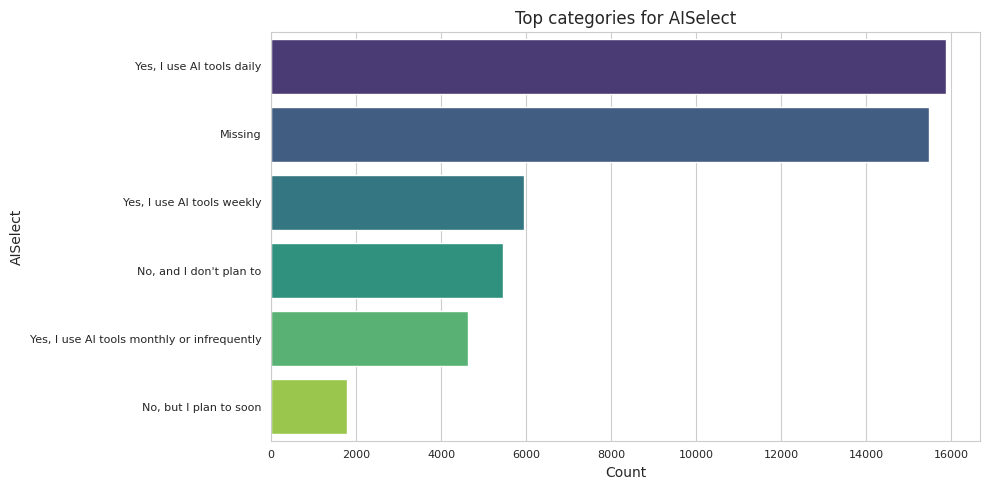

/tmp/ipykernel_13/1958854312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


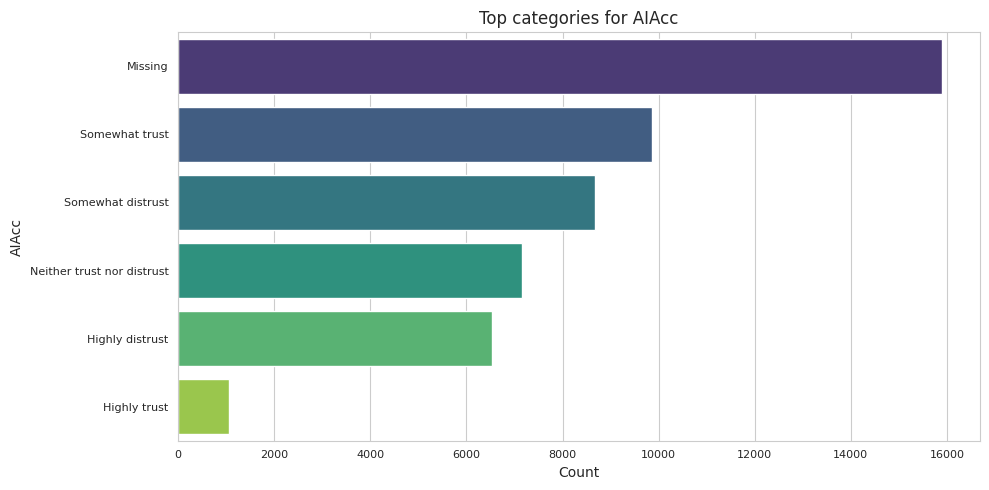

In [5]:
plot_folder = os.path.join(documents_folder, 'retained_column_plots')
os.makedirs(plot_folder, exist_ok=True)

# Histogram plot of numerical colunms
if len(numeric_cols) > 0:
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df_subset[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.tight_layout()
        plt.show()
        
# Correlation matrix
    corr = df_subset[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=' .2f', cmap='coolwarm', square=True)
    plt.title('Correlation matrix of retained numeric columns')
    plt.tight_layout()
    plt.show()

 # Bar plot of Categorical colunms
if len(cat_cols) > 0:
    for col in cat_cols:
        counts = df_subset[col].fillna('Missing').value_counts().head(15)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=counts.values, y=counts.index, palette='viridis')
        plt.title(f'Top categories for {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.show()


#### Question 1 and 2 answers:

With the descriptive analysis 
- We can see taht USA, Germany and India are the top respondents countries
- 84% of respondents are using AI tools.

## Section 3: Data preparation

- We filter on rows with yearly compensation of $1,000 or above as less than that doesn't seem reasonable. 
- We drop NA rows as it will difficults for imputations.
- We create dummies variables for categarical coluums.

In [6]:
# Cleaning the data for the model
df_tree = df_subset[df_subset['ConvertedCompYearly'] > 1000].dropna()
X = df_tree.drop(columns=['ConvertedCompYearly'])
y = df_tree['ConvertedCompYearly']

# Creating dummies variable for categorical variables
X_numeric = X.select_dtypes(include=['number'])
X_cat = X.select_dtypes(exclude=['number'])
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True, dummy_na=True, dtype=int)
X_final = pd.concat([X_numeric, X_cat_encoded], axis=1)


## Section 4: Data Modelling

In [7]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.20, random_state=42)

# Training the model
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)



DecisionTreeRegressor(max_depth=3, random_state=42)

## Section 5: Evaluation of the model

MSE: 16122831374.191298
R2 score: -0.8727837203594031


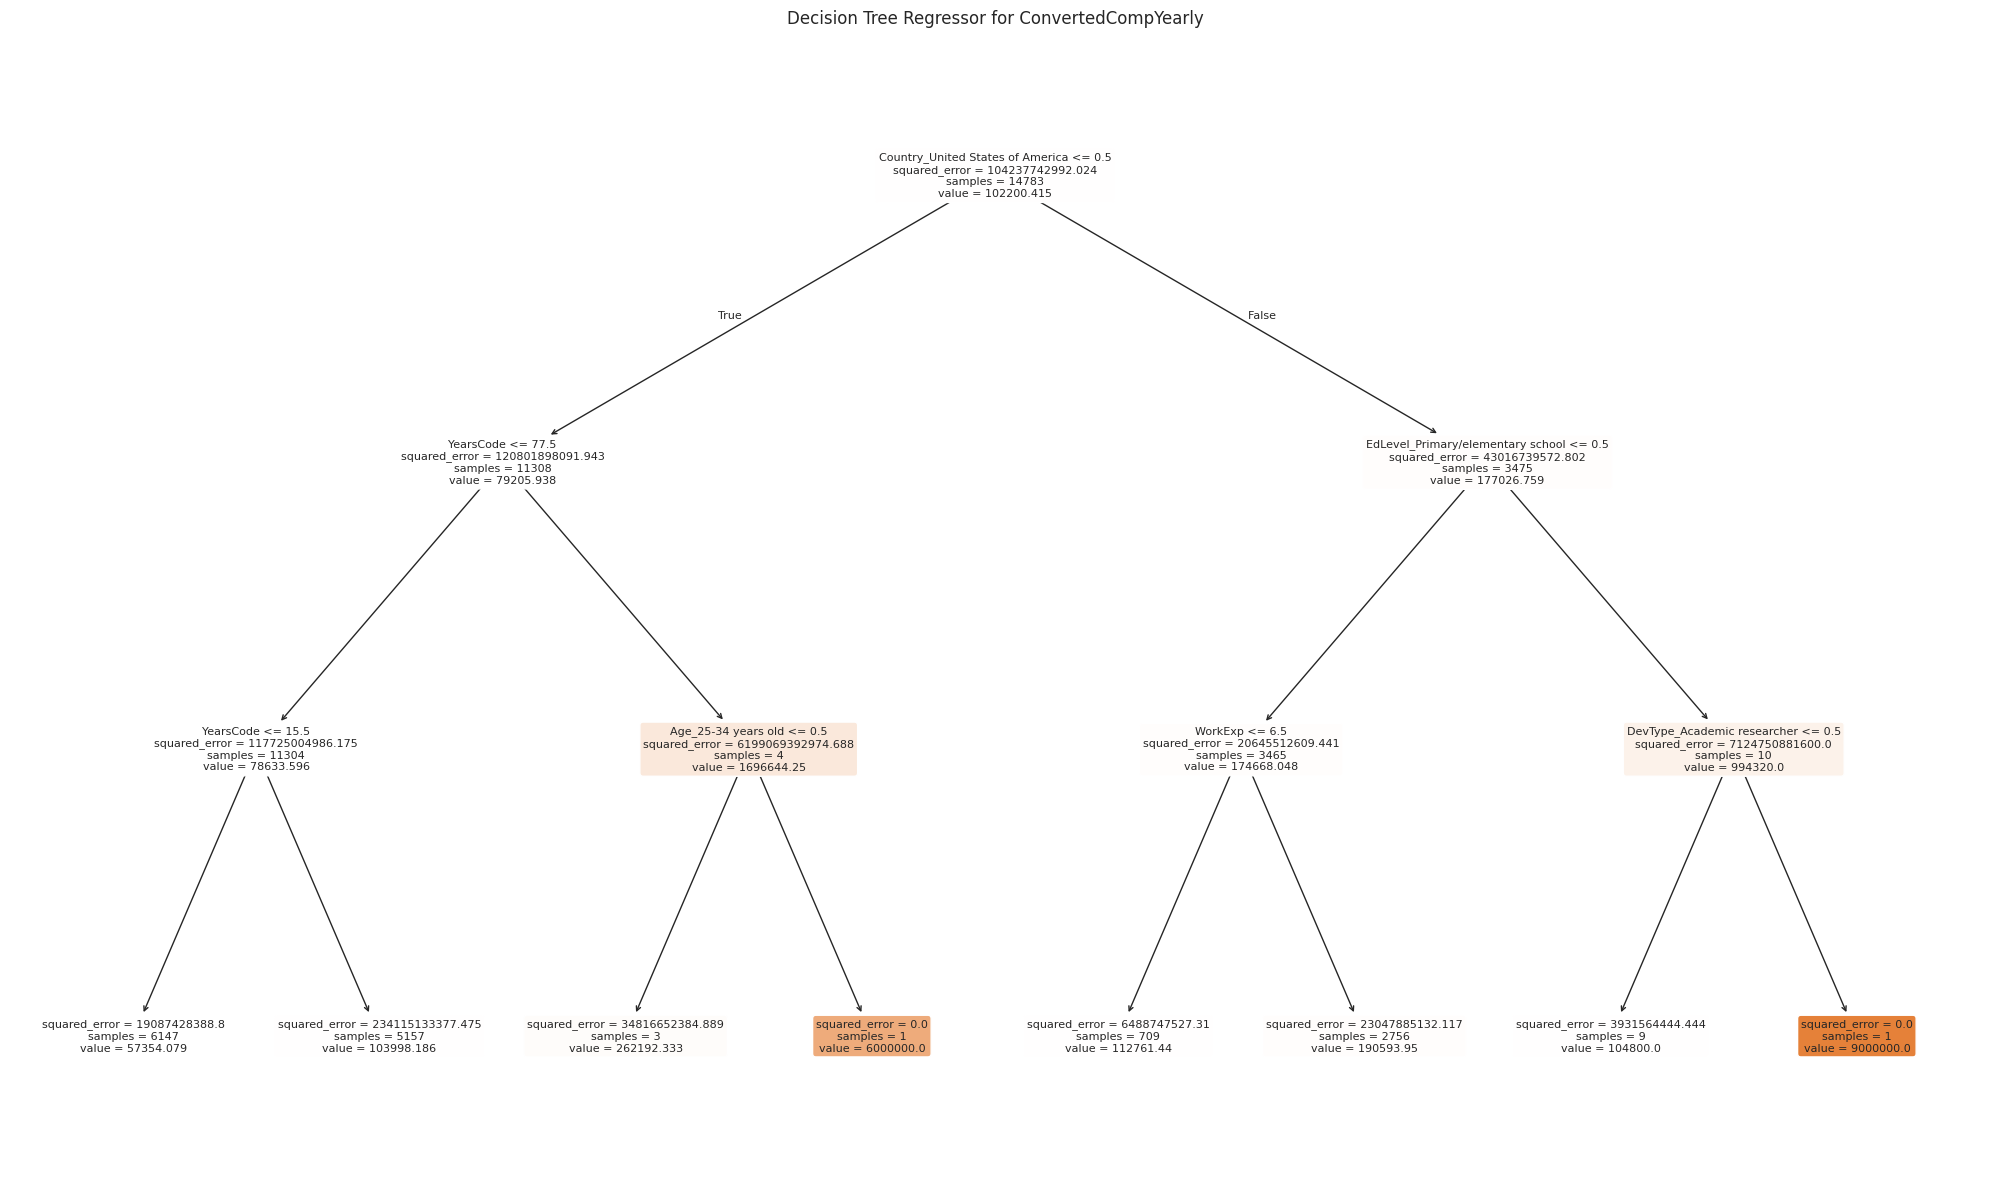

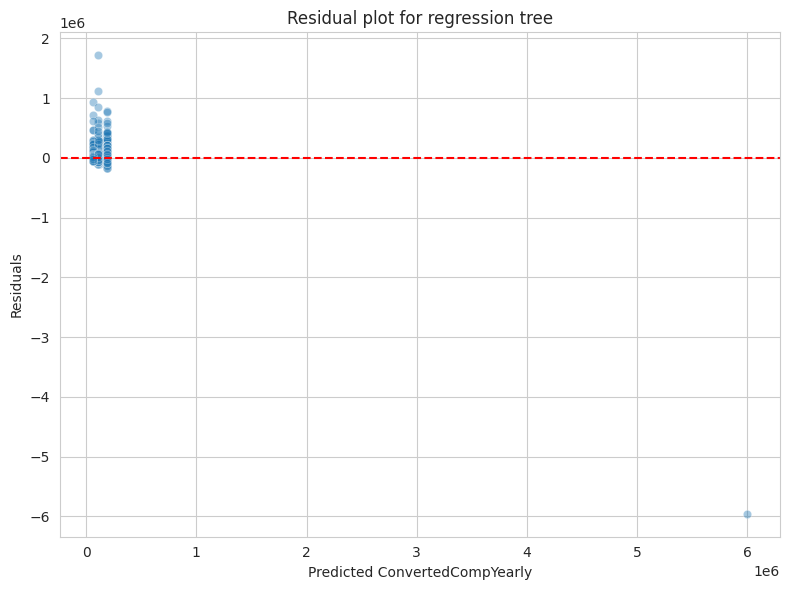

In [8]:
# Assessing predictive power
y_pred = tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('R2 score:', r2)

# Plotting the tree
plt.figure(figsize=(20, 12))
plot_tree(tree, feature_names=X_final.columns, filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree Regressor for ConvertedCompYearly')
plt.tight_layout()
plt.show()

# Plotting the residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=y_test - y_pred, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted ConvertedCompYearly')
plt.ylabel('Residuals')
plt.title('Residual plot for regression tree')
plt.tight_layout()
plt.show()

#### Question 3 and 4 answers:

After fitting the model we can conclude:
- Using AI doesn't have a significant impact on compensation
- The three important variables impacting compensation are Country, Year of coding experience and Education level

## Model Interpretation

Our r2 and MSE indicate that our model is not powerful and need for refinement, change of method or more significant variables.